# Comprehensive Experiments Summary: Cost-Sensitive Predictive Modeling

Documentation of all tested approaches for feature selection and modeling.
**Objective:** Maximize the metric Profit = (TP × 10) - (FP × 5) - (num_vars × 200)

In [16]:
import sys
sys.path.append('../')
from src.data_loader import load_project_data
from src.evaluation import calculate_profit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data loading and train/validation split

In [17]:
# Load data
X_train_full, y_train_full, X_test = load_project_data()
y_full = y_train_full.iloc[:, 0]

# Reproducible train/validation split (20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_full, test_size=0.2, random_state=67, stratify=y_full
)

print("Data loaded:")
print(f"   Train: {X_train.shape} | Validation: {X_val.shape} | Test: {X_test.shape}")
print(f"   Target class distribution: {y_train.value_counts().to_dict()}")

# Business parameters
PROFIT_THRESHOLD = 1.0 / 3.0  # threshold used by select_offer_indices
MAX_OFFERS = 1000
FEATURE_COST = 200

2026-06-05 20:08:49 - INFO - Data loaded — X_train: (5000, 500), y_train: (5000, 1), X_test: (5000, 500)


Data loaded:
   Train: (4000, 500) | Validation: (1000, 500) | Test: (5000, 500)
   Target class distribution: {0: 2010, 1: 1990}


## 2. Helper functions for model evaluation and result logging

In [18]:
def evaluate_model(model, X_train, X_val, y_train, y_val, features_list, approach_name):
    """Evaluate a model and return summary results."""
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    
    # Accuracy
    train_acc = (y_train_pred == y_train).mean()
    val_acc = (y_val_pred == y_val).mean()
    
    # Profit (using src.evaluation)
    profit = calculate_profit(
        y_true=y_val,
        y_pred_proba=y_val_proba,
        num_vars=len(features_list),
        debug=False
    )
    
    return {
        'Approach': approach_name,
        'Num_Variables': len(features_list),
        'Train_Accuracy': train_acc,
        'Val_Accuracy': val_acc,
        'Profit_EUR': profit,
        'Variables': features_list,
        'Model': model
    }

# Storage for all notebook experiment results
results_log = []

## 3. Experiment 1: LogisticRegression on top correlations

In [19]:
# Compute correlations with the target
df_eda = pd.concat([X_train, y_train], axis=1)
correlations = df_eda.corr()[y_train.name].drop(y_train.name)
top_correlations_1 = correlations.abs().sort_values(ascending=False).head(1)
top_correlations_5 = correlations.abs().sort_values(ascending=False).head(5)

print(f"Top 1 feature (correlation): {top_correlations_1.index[0]} ({top_correlations_1.values[0]:.3f})")
print(f"Top 5 features (correlation): {list(top_correlations_5.index)}")

# Exp 1a: Top 1 feature
features_exp1a = list(top_correlations_1.index)
model_exp1a = LogisticRegression(random_state=67, max_iter=1000)
result_exp1a = evaluate_model(
    model_exp1a, 
    X_train[features_exp1a], X_val[features_exp1a], 
    y_train, y_val, 
    features_exp1a, 
    "LR - Top 1 feature"
)
results_log.append(result_exp1a)
print(f"Exp 1a result: {result_exp1a}")

# Exp 1b: Top 5 features
features_exp1b = list(top_correlations_5.index)
model_exp1b = LogisticRegression(random_state=67, max_iter=1000)
result_exp1b = evaluate_model(
    model_exp1b,
    X_train[features_exp1b], X_val[features_exp1b],
    y_train, y_val,
    features_exp1b,
    "LR - Top 5 features"
)
results_log.append(result_exp1b)
print(f"Exp 1b result: {result_exp1b}")

Top 1 feature (correlation): V390 (0.121)
Top 5 features (correlation): ['V390', 'V224', 'V161', 'V32', 'V175']
Exp 1a result: {'Approach': 'LR - Top 1 feature', 'Num_Variables': 1, 'Train_Accuracy': np.float64(0.539), 'Val_Accuracy': np.float64(0.533), 'Profit_EUR': 2295.0, 'Variables': ['V390'], 'Model': LogisticRegression(max_iter=1000, random_state=67)}
Exp 1b result: {'Approach': 'LR - Top 5 features', 'Num_Variables': 5, 'Train_Accuracy': np.float64(0.5755), 'Val_Accuracy': np.float64(0.557), 'Profit_EUR': 1490.0, 'Variables': ['V390', 'V224', 'V161', 'V32', 'V175'], 'Model': LogisticRegression(max_iter=1000, random_state=67)}


## 4. Experiment 2: LogisticRegression with L1 and feature selection

In [20]:
# LogisticRegression with L1 regularization on all features
model_l1 = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, l1_ratio=1.0, C=0.01, random_state=67)
model_l1.fit(X_train, y_train)

# Extract features with non-zero coefficients
non_zero_indices = np.where(model_l1.coef_[0] != 0)[0]
features_exp2 = X_train.columns[non_zero_indices].tolist()

print(f"L1 selected {len(features_exp2)} features: {features_exp2}")

# Evaluate L1 model
result_exp2 = evaluate_model(
    LogisticRegression(penalty='l1', solver='saga', max_iter=1000, l1_ratio=1.0, C=0.01, random_state=67),
    X_train[features_exp2], X_val[features_exp2],
    y_train, y_val,
    features_exp2,
    "LR - L1 Regularization"
)
results_log.append(result_exp2)
print(f"Exp 2 result: Profit={result_exp2['Profit_EUR']:.0f} EUR, Variables={result_exp2['Num_Variables']}")

L1 selected 52 features: ['V3', 'V24', 'V32', 'V34', 'V50', 'V64', 'V86', 'V88', 'V94', 'V98', 'V99', 'V107', 'V108', 'V152', 'V153', 'V161', 'V162', 'V174', 'V175', 'V199', 'V203', 'V205', 'V213', 'V220', 'V221', 'V224', 'V229', 'V231', 'V256', 'V268', 'V273', 'V282', 'V295', 'V312', 'V317', 'V328', 'V329', 'V341', 'V345', 'V346', 'V365', 'V378', 'V383', 'V390', 'V393', 'V419', 'V422', 'V424', 'V428', 'V433', 'V440', 'V495']
Exp 2 result: Profit=-7955 EUR, Variables=52


## 5. Experiment 3: Boruta for feature selection

In [21]:
try:
    from boruta import BorutaPy
    
    # Feature selection with Boruta
    rf_estimator = RandomForestClassifier(
        n_estimators=100, random_state=67, n_jobs=-1, 
        class_weight='balanced', max_depth=5
    )
    
    boruta = BorutaPy(rf_estimator, n_estimators='auto', random_state=67, max_iter=50)
    boruta.fit(X_train.values, y_train.values)
    
    confirmed_features = X_train.columns[boruta.support_].tolist()
    tentative_features = X_train.columns[boruta.support_weak_].tolist()
    
    print(f"Confirmed features ({len(confirmed_features)}): {confirmed_features}")
    print(f"Tentative features ({len(tentative_features)}): {tentative_features}")
    
    # Use only confirmed features
    features_exp3 = confirmed_features
    
    # Evaluate model on Boruta features
    result_exp3 = evaluate_model(
        LogisticRegression(random_state=67, max_iter=1000),
        X_train[features_exp3], X_val[features_exp3],
        y_train, y_val,
        features_exp3,
        "LR - Boruta Confirmed"
    )
    results_log.append(result_exp3)
    print(f"Exp 3 result: Profit={result_exp3['Profit_EUR']:.0f} EUR, Variables={result_exp3['Num_Variables']}")
    
except ImportError:
    print("Boruta is not installed, skipping this experiment")

Boruta is not installed, skipping this experiment


## 6. Experiment 4: HistGradientBoosting on Boruta features

In [22]:
try:
    # HistGradientBoosting on Boruta features
    model_hgb = HistGradientBoostingClassifier(
        max_iter=50, max_depth=3, min_samples_leaf=100,
        l2_regularization=2.0, learning_rate=0.05, random_state=67
    )
    
    result_exp4 = evaluate_model(
        model_hgb,
        X_train[features_exp3], X_val[features_exp3],
        y_train, y_val,
        features_exp3,
        "HistGradientBoosting - Boruta"
    )
    results_log.append(result_exp4)
    print(f"Exp 4 result: Profit={result_exp4['Profit_EUR']:.0f} EUR, Variables={result_exp4['Num_Variables']}")
except NameError:
    print("Boruta was not available, skipping HistGradientBoosting on Boruta features")

Boruta was not available, skipping HistGradientBoosting on Boruta features


## 6 i 3/4 Eksperymenty Igora

In [23]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Krok 1: Trenowanie bazowego modelu LightGBM do oceny ważności wszystkich cech...

Krok 4: Rozpoczęcie iteracyjnego sprawdzania zysków (Koszt: 200 EUR za cechę)...

Eksperyment zakończony! Najlepszy zysk: 2215 EUR przy użyciu dokładnie 1 cech.


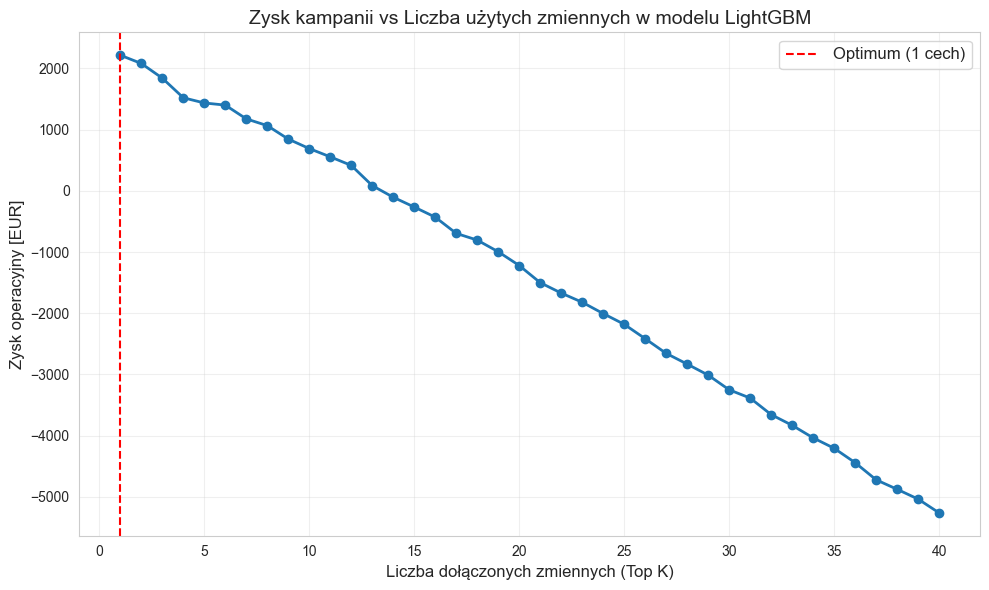

In [24]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Krok 1: Trenowanie bazowego modelu LightGBM do oceny ważności wszystkich cech...")
# Szybki model na pełnych danych, żeby złapać sygnał od najważniejszych zmiennych
lgbm_base = lgb.LGBMClassifier(
    n_estimators=100, max_depth=10, learning_rate=0.05, random_state=67, n_jobs=-1, verbose=-1
)
lgbm_base.fit(X_train, y_train.values.ravel())

# Zamiast domyślnego lgbm_base.feature_importances_ użyj:
importance_values = lgbm_base.booster_.feature_importance(importance_type='gain')

feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance_values
}).sort_values(by='Importance', ascending=False)

top_all_features = feature_imp_df['Feature'].tolist()

# Krok 3: Pętla iterująca po różnej liczbie cech (np. od 1 do 40)
k_values = list(range(1, 41)) # Testujemy użycie od 1 do 40 zmiennych
profits = []

best_profit = -np.inf
best_k = 0

print("\nKrok 4: Rozpoczęcie iteracyjnego sprawdzania zysków (Koszt: 200 EUR za cechę)...")
for k in k_values:
    current_features = top_all_features[:k]
    
    # Definiujemy docelowy model dla danej iteracji
    model_iter = lgb.LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.05, random_state=67, n_jobs=-1, verbose=-1
    )
    
    # Używamy Twojej funkcji ewaluacyjnej
    exp_name = f"LGBM - Top {k} features"
    result_iter = evaluate_model(
        model_iter,
        X_train[current_features], X_val[current_features],
        y_train, y_val,
        current_features,
        exp_name
    )
    
    current_profit = result_iter['Profit_EUR']
    profits.append(current_profit)
    results_log.append(result_iter)
    
    # Śledzimy najlepszy wynik
    if current_profit > best_profit:
        best_profit = current_profit
        best_k = k
        
print(f"\nEksperyment zakończony! Najlepszy zysk: {best_profit:.0f} EUR przy użyciu dokładnie {best_k} cech.")

# Krok 5: Rysowanie wykresu decyzyjnego
plt.figure(figsize=(10, 6))
plt.plot(k_values, profits, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Optimum ({best_k} cech)')

# Stylizowanie wykresu
plt.title('Zysk kampanii vs Liczba użytych zmiennych w modelu LightGBM', fontsize=14)
plt.xlabel('Liczba dołączonych zmiennych (Top K)', fontsize=12)
plt.ylabel('Zysk operacyjny [EUR]', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif


print("Krok 1: Wstępna redukcja 500 -> 50 zmiennych za pomocą Mutual Information...")
# Liczymy Mutual Information (szybki filtr nieliniowy)
mi_scores = mutual_info_classif(X_train, y_train.values.ravel(), random_state=67)
mi_df = pd.DataFrame({'Feature': X_train.columns, 'MI_Score': mi_scores})

# Wybieramy top 50 cech do właściwego eksperymentu
top_50_candidates = mi_df.sort_values('MI_Score', ascending=False).head(50)['Feature'].tolist()
print(f"Wytypowano 50 kandydatów. Przechodzę do Zachłannej Optymalizacji Zysku.\n")

# Krok 2: Konfiguracja Profit-Driven SFS
selected_features = [] # Tu będziemy odkładać zwycięskie zmienne
best_overall_profit = 0 # Zaczynamy od zera
remaining_features = top_50_candidates.copy()

# Szybki model używany do oceniania
eval_model = HistGradientBoostingClassifier(
    max_iter=50, max_depth=5, learning_rate=0.1, random_state=67
)

step = 1
while remaining_features:
    print(f"--- Krok {step}: Szukanie najlepszej zmiennej (pozostało kandydatów: {len(remaining_features)}) ---")
    best_profit_this_step = -np.inf
    best_feature_this_step = None
    best_result_log_this_step = None
    
    # Testujemy każdego kandydata osobno z dotychczas wybranymi cechami
    for candidate in remaining_features:
        current_test_features = selected_features + [candidate]
        
        # Wytrenuj model i użyj Twojej funkcji evaluate_model
        exp_name = f"SFS_Step_{step}_{candidate}"
        result = evaluate_model(
            eval_model,
            X_train[current_test_features], X_val[current_test_features],
            y_train, y_val,
            current_test_features,
            exp_name
        )
        
        profit = result['Profit_EUR']
        
        # Zapisujemy najlepszy wynik w tej iteracji
        if profit > best_profit_this_step:
            best_profit_this_step = profit
            best_feature_this_step = candidate
            best_result_log_this_step = result
            
    # Krok 3: Decyzja biznesowa (Czy dodanie tej cechy się opłacało?)
    print(f"Najlepszy kandydat to: {best_feature_this_step} z wynikiem {best_profit_this_step:.0f} EUR")
    
    if best_profit_this_step > best_overall_profit:
        # Opłacało się! Dodajemy cechę na stałe i szukamy dalej
        selected_features.append(best_feature_this_step)
        remaining_features.remove(best_feature_this_step)
        best_overall_profit = best_profit_this_step
        results_log.append(best_result_log_this_step)
        print(f"ZATWIERDZONO: Dodano {best_feature_this_step} do modelu. Aktualny portfel: {selected_features}\n")
        step += 1
    else:
        # Nie opłacało się. Dodanie jakiejkolwiek kolejnej cechy przynosi straty (koszt 200 EUR jest za duży).
        print(f"\nODRZUCONO: Zaden z kandydatów nie pobił dotychczasowego zysku ({best_overall_profit:.0f} EUR).")
        print("Zatrzymuję algorytm. Osiągnięto absolutne maksimum profitu.")
        break

print("\n" + "="*50)
print("FINAŁ ZACHŁANNEJ OPTYMALIZACJI:")
print(f"Ostateczny zysk: {best_overall_profit:.0f} EUR")
print(f"Wybrane, najbardziej dochodowe zmienne ({len(selected_features)}): {selected_features}")
print("="*50)


Krok 1: Wstępna redukcja 500 -> 50 zmiennych za pomocą Mutual Information...
Wytypowano 50 kandydatów. Przechodzę do Zachłannej Optymalizacji Zysku.

--- Krok 1: Szukanie najlepszej zmiennej (pozostało kandydatów: 50) ---
Najlepszy kandydat to: V321 z wynikiem 2320 EUR
ZATWIERDZONO: Dodano V321 do modelu. Aktualny portfel: ['V321']

--- Krok 2: Szukanie najlepszej zmiennej (pozostało kandydatów: 49) ---
Najlepszy kandydat to: V21 z wynikiem 2120 EUR

ODRZUCONO: Zaden z kandydatów nie pobił dotychczasowego zysku (2320 EUR).
Zatrzymuję algorytm. Osiągnięto absolutne maksimum profitu.

FINAŁ ZACHŁANNEJ OPTYMALIZACJI:
Ostateczny zysk: 2320 EUR
Wybrane, najbardziej dochodowe zmienne (1): ['V321']


## 7. Summary table: accuracy, profit, number of variables

In [26]:
# Load results from experiment_results.csv (produced by run_experiments.py)
import os
results_csv_path = '../experiment_results.csv'
if os.path.exists(results_csv_path):
    exp_results = pd.read_csv(results_csv_path)
    print("\nResults from automated experiments (run_experiments.py):")
    print(exp_results[['name', 'profit', 'features']].to_string())
    
    # Parse features string to list
    exp_results['num_features'] = exp_results['features'].apply(
        lambda x: len(eval(x)) if isinstance(x, str) else 0
    )
    print(f"\nBest result: {exp_results.loc[exp_results['profit'].idxmax(), 'name']} with profit {exp_results['profit'].max():.0f} EUR")

# Create DataFrame from notebook experiments
results_df = pd.DataFrame(results_log)
results_df = results_df[['Approach', 'Num_Variables', 'Train_Accuracy', 'Val_Accuracy', 'Profit_EUR']].sort_values('Profit_EUR', ascending=False)

print("\n\nSummary table of all notebook experiments:")
print(results_df.to_string(index=False))
print(f"\nWINNER: {results_df.iloc[0]['Approach']} - Profit: {results_df.iloc[0]['Profit_EUR']:.0f} EUR")


Results from automated experiments (run_experiments.py):
                                                    name  profit                                         features
0    Exp 1: Standard (Filter 50, Embedded 15, Corr 0.85)    6070  ['V160', 'V11', 'V191', 'V342', 'V380', 'V215']
1   Exp 2: Wide Net (Filter 100, Embedded 30, Corr 0.90)    5440                         ['V224', 'V160', 'V390']
2  Exp 3: Strict Net (Filter 30, Embedded 10, Corr 0.80)    6070  ['V160', 'V11', 'V191', 'V342', 'V380', 'V215']

Best result: Exp 1: Standard (Filter 50, Embedded 15, Corr 0.85) with profit 6070 EUR


Summary table of all notebook experiments:
              Approach  Num_Variables  Train_Accuracy  Val_Accuracy  Profit_EUR
       SFS_Step_1_V321              1         0.57050         0.548      2320.0
    LR - Top 1 feature              1         0.53900         0.533      2295.0
 LGBM - Top 1 features              1         0.59725         0.549      2215.0
 LGBM - Top 2 features            

## 8. Comparative visualizations of models and feature selection

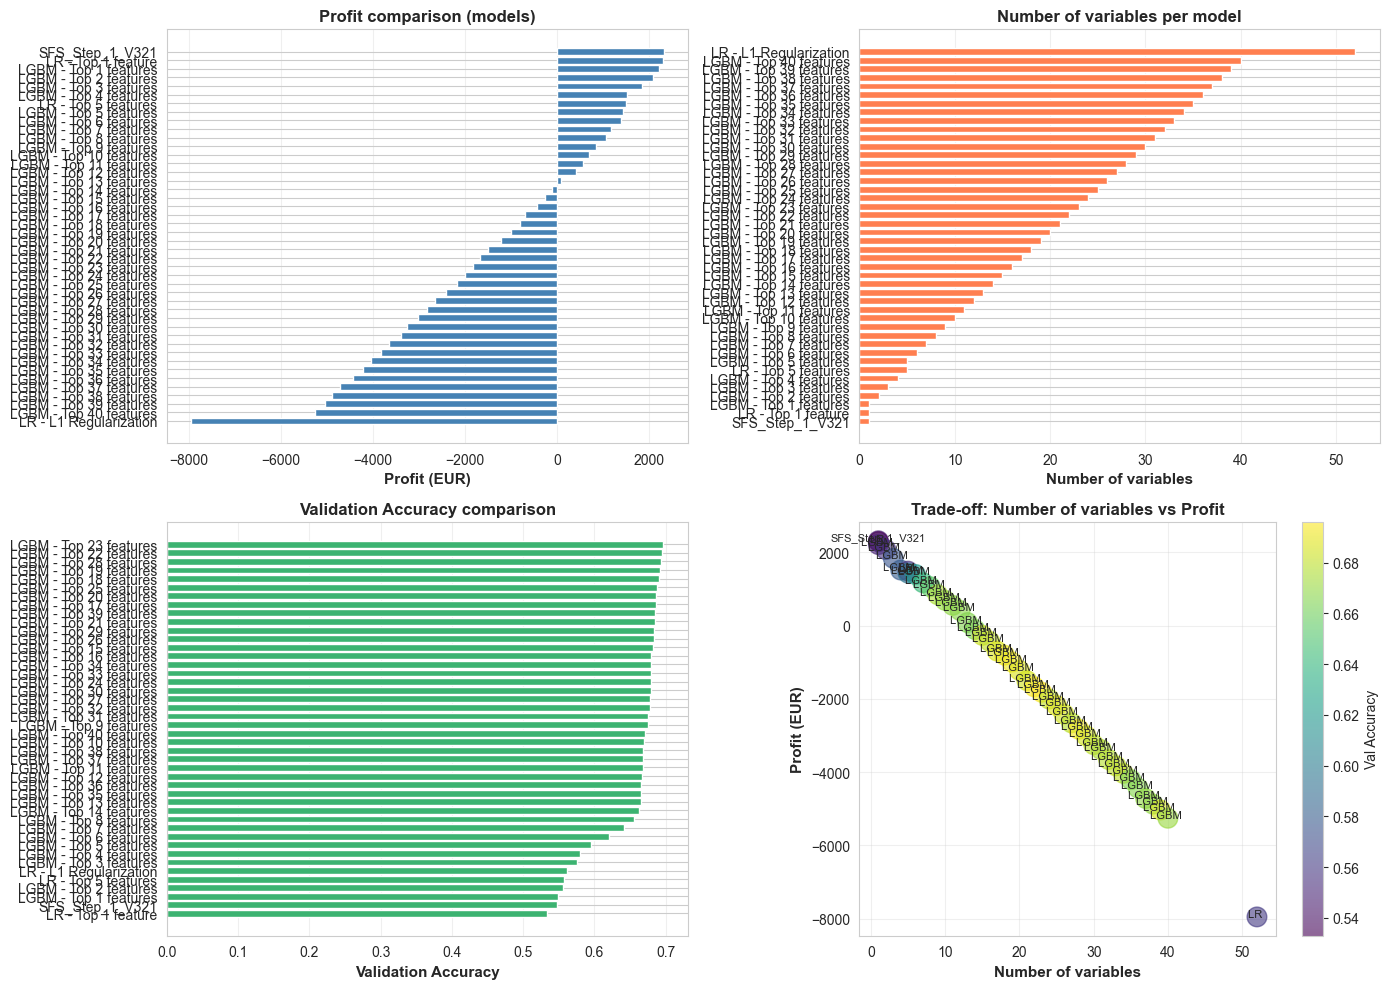

Visualizations generated.


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Profit comparison
ax1 = axes[0, 0]
results_df_sorted = results_df.sort_values('Profit_EUR', ascending=True)
ax1.barh(results_df_sorted['Approach'], results_df_sorted['Profit_EUR'], color='steelblue')
ax1.set_xlabel('Profit (EUR)', fontsize=11, fontweight='bold')
ax1.set_title('Profit comparison (models)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Number of variables
ax2 = axes[0, 1]
results_df_sorted2 = results_df.sort_values('Num_Variables', ascending=True)
ax2.barh(results_df_sorted2['Approach'], results_df_sorted2['Num_Variables'], color='coral')
ax2.set_xlabel('Number of variables', fontsize=11, fontweight='bold')
ax2.set_title('Number of variables per model', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Validation Accuracy
ax3 = axes[1, 0]
results_df_sorted3 = results_df.sort_values('Val_Accuracy', ascending=True)
ax3.barh(results_df_sorted3['Approach'], results_df_sorted3['Val_Accuracy'], color='mediumseagreen')
ax3.set_xlabel('Validation Accuracy', fontsize=11, fontweight='bold')
ax3.set_title('Validation Accuracy comparison', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Scatter: Number of variables vs Profit
ax4 = axes[1, 1]
scatter = ax4.scatter(results_df['Num_Variables'], results_df['Profit_EUR'], 
                     s=200, alpha=0.6, c=results_df['Val_Accuracy'], cmap='viridis')
for idx, row in results_df.iterrows():
    ax4.annotate(row['Approach'].split('-')[0], 
                (row['Num_Variables'], row['Profit_EUR']),
                fontsize=8, ha='center')
ax4.set_xlabel('Number of variables', fontsize=11, fontweight='bold')
ax4.set_ylabel('Profit (EUR)', fontsize=11, fontweight='bold')
ax4.set_title('Trade-off: Number of variables vs Profit', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Val Accuracy', fontsize=10)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations generated.")

## 9. Log analysis and final recommendations

## Part III: Run experiments from `src`

In [28]:
import os
from pathlib import Path

# Load experiment results
project_root = Path('..').resolve()
csv_path = project_root / 'experiment_results.csv'
log_path = project_root / 'experiments.log'

if csv_path.exists():
    experiments_df = pd.read_csv(csv_path)
    print("Experiment results loaded from experiment_results.csv:")
    print(experiments_df.to_string())
    print(f"\nFound {len(experiments_df)} experiments")
else:
    print(f"File {csv_path} not found")
    experiments_df = None

if log_path.exists():
    with open(log_path, 'r', encoding='utf-8') as f:
        log_content = f.read()
    print(f"\nExperiment logs (last 50 lines):")
    print('\n'.join(log_content.split('\n')[-50:]))
else:
    print(f"File {log_path} not found")

Experiment results loaded from experiment_results.csv:
                                                    name  profit                                         features                                                                                                                       params
0    Exp 1: Standard (Filter 50, Embedded 15, Corr 0.85)    6070  ['V160', 'V11', 'V191', 'V342', 'V380', 'V215']  {'min_samples_leaf': 5, 'max_leaf_nodes': 15, 'max_iter': 300, 'learning_rate': np.float64(0.02), 'l2_regularization': 0.1}
1   Exp 2: Wide Net (Filter 100, Embedded 30, Corr 0.90)    5440                         ['V224', 'V160', 'V390']  {'min_samples_leaf': 5, 'max_leaf_nodes': 15, 'max_iter': 300, 'learning_rate': np.float64(0.02), 'l2_regularization': 0.1}
2  Exp 3: Strict Net (Filter 30, Embedded 10, Corr 0.80)    6070  ['V160', 'V11', 'V191', 'V342', 'V380', 'V215']  {'min_samples_leaf': 5, 'max_leaf_nodes': 15, 'max_iter': 300, 'learning_rate': np.float64(0.02), 'l2_regularizat

### Comparison of experiment results


Experiment ranking:
                                                 name  profit  num_features
  Exp 1: Standard (Filter 50, Embedded 15, Corr 0.85)    6070             6
Exp 3: Strict Net (Filter 30, Embedded 10, Corr 0.80)    6070             6
 Exp 2: Wide Net (Filter 100, Embedded 30, Corr 0.90)    5440             3


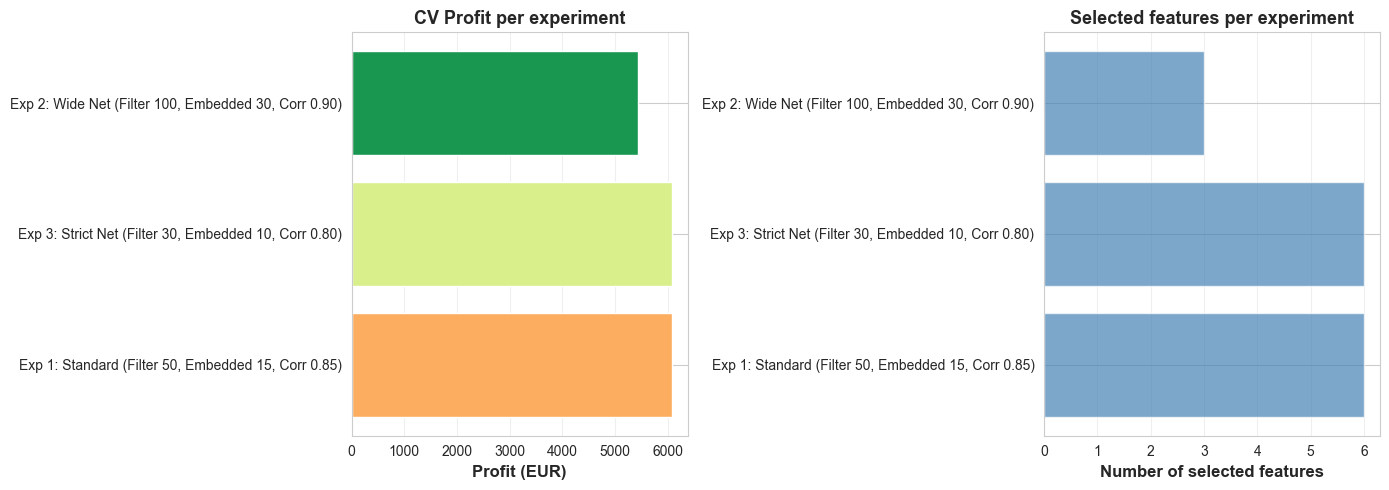

Visualization saved as experiments_comparison.png


In [29]:
if experiments_df is not None:
    # Comparison table
    comparison_df = experiments_df[['name', 'profit', 'features']].copy()
    comparison_df['num_features'] = comparison_df['features'].apply(lambda x: len(eval(x)) if isinstance(x, str) else 0)
    comparison_df = comparison_df.sort_values('profit', ascending=False)
    
    print("\nExperiment ranking:")
    print(comparison_df[['name', 'profit', 'num_features']].to_string(index=False))
    
    # Profit plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Profit vs features
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(comparison_df)))
    axes[0].barh(comparison_df['name'], comparison_df['profit'], color=colors)
    axes[0].set_xlabel('Profit (EUR)', fontsize=12, fontweight='bold')
    axes[0].set_title('CV Profit per experiment', fontsize=13, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Number of features
    axes[1].barh(comparison_df['name'], comparison_df['num_features'], color='steelblue', alpha=0.7)
    axes[1].set_xlabel('Number of selected features', fontsize=12, fontweight='bold')
    axes[1].set_title('Selected features per experiment', fontsize=13, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(project_root / 'experiments_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Visualization saved as experiments_comparison.png")
else:
    print("No experiment data to display")

### Test the winner on the validation set

In [30]:
from src.evaluation import select_offer_indices, calculate_profit
from src.run_optimization import tune_hgb_for_profit, build_calibrated_model
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

if experiments_df is not None:
    # Select winner
    winner_idx = experiments_df['profit'].idxmax()
    winner = experiments_df.loc[winner_idx]
    winner_features = eval(winner['features'])
    winner_params = eval(winner['params'])
    
    print(f"WINNER: {winner['name']}")
    print(f"   CV Profit: {winner['profit']:,.0f} EUR")
    print(f"   Features: {winner_features}")
    print(f"   Number of features: {len(winner_features)}")
    
    # Train the winner model on the full training set
    X_train_winner = X_train_full[winner_features]
    X_val_winner = X_val[winner_features]
    X_test_winner = X_test[winner_features]
    
    # Build ensemble
    hgb_model = HistGradientBoostingClassifier(random_state=67, **winner_params)
    rf_model = RandomForestClassifier(random_state=67, n_estimators=300, max_depth=8, class_weight='balanced')
    lr_model = make_pipeline(StandardScaler(), LogisticRegression(random_state=67, max_iter=1000, C=0.01))
    mlp_model = make_pipeline(StandardScaler(), MLPClassifier(random_state=67, hidden_layer_sizes=(64, 32), max_iter=500))
    svm_model = make_pipeline(StandardScaler(), SVC(probability=True, random_state=67, class_weight='balanced'))
    
    from sklearn.ensemble import VotingClassifier
    ensemble = VotingClassifier(
        estimators=[('hgb', hgb_model), ('rf', rf_model), ('lr', lr_model), ('mlp', mlp_model), ('svm', svm_model)],
        voting='soft'
    )
    
    # Calibration
    calibration_cv = min(5, int(y_full.value_counts().min()))
    final_model = build_calibrated_model(ensemble, n_folds=calibration_cv) if calibration_cv >= 2 else ensemble
    
    # Training
    print("\nTraining the ensemble models...")
    final_model.fit(X_train_winner, y_full)
    
    # Validation predictions
    y_val_pred = final_model.predict(X_val_winner)
    y_val_proba = final_model.predict_proba(X_val_winner)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    auc = roc_auc_score(y_val, y_val_proba)
    
    print(f"\nValidation metrics:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   ROC-AUC:   {auc:.4f}")
    
    # Profit on validation
    top_indices_val = select_offer_indices(y_val_proba, threshold=PROFIT_THRESHOLD, max_offers=MAX_OFFERS)
    val_profit = calculate_profit(
        y_true=y_val.values,
        y_pred_proba=y_val_proba,
        num_vars=len(winner_features),
        debug=False
    )
    print(f"\nValidation profit: {val_profit:,.0f} EUR")

WINNER: Exp 1: Standard (Filter 50, Embedded 15, Corr 0.85)
   CV Profit: 6,070 EUR
   Features: ['V160', 'V11', 'V191', 'V342', 'V380', 'V215']
   Number of features: 6

Training the ensemble models...

Validation metrics:
   Accuracy:  0.7360
   Precision: 0.7566
   Recall:    0.6928
   F1-Score:  0.7233
   ROC-AUC:   0.8163

Validation profit: 1,790 EUR


### Test set predictions

Predicting on the test set...

Test set results:
   Number of selected offers: 1000
   Mean probability of selected offers: 0.7321
   Min/Max probability of selected offers: 0.6621 / 0.8456


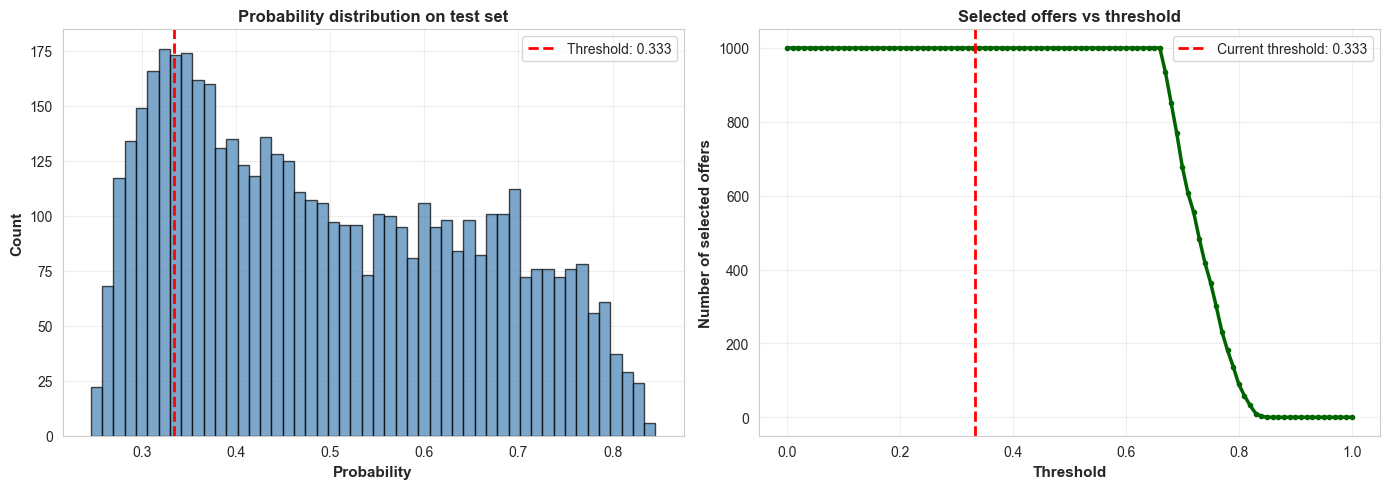

Visualization saved as test_predictions.png


In [31]:
if experiments_df is not None:
    print("Predicting on the test set...")
    y_test_pred = final_model.predict(X_test_winner)
    y_test_proba = final_model.predict_proba(X_test_winner)[:, 1]
    
    # Select top offers
    top_indices_test = select_offer_indices(y_test_proba, threshold=PROFIT_THRESHOLD, max_offers=MAX_OFFERS)
    
    print(f"\nTest set results:")
    print(f"   Number of selected offers: {len(top_indices_test)}")
    print(f"   Mean probability of selected offers: {y_test_proba[top_indices_test].mean():.4f}")
    print(f"   Min/Max probability of selected offers: {y_test_proba[top_indices_test].min():.4f} / {y_test_proba[top_indices_test].max():.4f}")
    
    # Plot probability distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of all probabilities
    axes[0].hist(y_test_proba, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0].axvline(PROFIT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold: {PROFIT_THRESHOLD:.3f}')
    axes[0].set_xlabel('Probability', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[0].set_title('Probability distribution on test set', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Number of offers vs threshold
    thresholds = np.linspace(0, 1, 101)
    offer_counts = [len(select_offer_indices(y_test_proba, threshold=t, max_offers=MAX_OFFERS)) for t in thresholds]
    
    axes[1].plot(thresholds, offer_counts, linewidth=2.5, color='darkgreen', marker='o', markersize=3)
    axes[1].axvline(PROFIT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Current threshold: {PROFIT_THRESHOLD:.3f}')
    axes[1].set_xlabel('Threshold', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Number of selected offers', fontsize=11, fontweight='bold')
    axes[1].set_title('Selected offers vs threshold', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(project_root / 'test_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Visualization saved as test_predictions.png")

### Summary and submission generation

In [32]:
if experiments_df is not None:
    print("="*70)
    print("FINAL SUMMARY")
    print("="*70)
    
    # Summary table
    summary_data = {
        'Metric': [
            'Winning experiment',
            'CV Profit',
            'Number of variables',
            'Variables',
            'Val Accuracy',
            'Val Precision',
            'Val Recall',
            'Val F1-Score',
            'Val ROC-AUC',
            'Val Profit',
            'Test Offers',
            'Decision threshold'
        ],
        'Value': [
            winner['name'],
            f"{winner['profit']:,.0f} EUR",
            len(winner_features),
            ', '.join(winner_features),
            f"{accuracy:.4f}",
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{f1:.4f}",
            f"{auc:.4f}",
            f"{val_profit:,.0f} EUR",
            len(top_indices_test),
            f"{PROFIT_THRESHOLD:.4f}"
        ]
    }
    
    summary_df = pd.DataFrame(summary_data)
    print("\n" + summary_df.to_string(index=False))
    
    # Save submission files (if not exist)
    team_name = "123456_98765_98764"
    obs_path = project_root / f"{team_name}_obs.txt"
    vars_path = project_root / f"{team_name}_vars.txt"
    
    if not obs_path.exists() or not vars_path.exists():
        submission_indices = top_indices_test + 1
        raw_var_indices = [int(f.replace('V', '')) for f in winner_features]
        
        pd.Series(submission_indices).to_csv(obs_path, index=False, header=False)
        pd.DataFrame(raw_var_indices).to_csv(vars_path, index=False, header=False)
        
        print(f"Submission files generated:")
        print(f"   {obs_path.name} ({len(submission_indices)} offers)")
        print(f"   {vars_path.name} ({len(raw_var_indices)} variables)")
    else:
        print("Submission files already exist")


FINAL SUMMARY

             Metric                                               Value
 Winning experiment Exp 1: Standard (Filter 50, Embedded 15, Corr 0.85)
          CV Profit                                           6,070 EUR
Number of variables                                                   6
          Variables                   V160, V11, V191, V342, V380, V215
       Val Accuracy                                              0.7360
      Val Precision                                              0.7566
         Val Recall                                              0.6928
       Val F1-Score                                              0.7233
        Val ROC-AUC                                              0.8163
         Val Profit                                           1,790 EUR
        Test Offers                                                1000
 Decision threshold                                              0.3333
Submission files already exist
